In [1]:
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.colors import (ListedColormap, LinearSegmentedColormap,
                               BoundaryNorm, Normalize, to_hex)
from matplotlib.patches import Patch

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster, dendrogram
from Bio import Phylo

In [2]:
# inputs 
M2OR_PATH  = Path("../../../Model/Data_Preparation/processed/m2or_pairs_model.csv")
PRED_DIR   = Path("../../predictions/aggregated/Reference_Tree_Predictions")
BIN_PATH   = PRED_DIR / "reference_median_prediction_wide.csv"    # 0/1
PROB_PATH  = PRED_DIR / "reference_median_probability_wide.csv"   # probabilities
TREE_PATH  = Path("../../../Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree")
CLASS_PATH = Path("../../../Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv")

# constants 
N_CLUSTERS = 7          # ligand (column) clusters
FIGSIZE    = (4, 3)
DPI        = 300

# output
FIG_DIR = Path("./Figures"); FIG_DIR.mkdir(exist_ok=True)

def savefig(fig, name):
    for ext in ("svg"):
        fig.savefig(FIG_DIR / f"{name}.svg", format="svg", bbox_inches="tight")
    # for ext in ("svg", "png"):
    #     fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight",
    #                 transparent=True, dpi=DPI)

In [3]:
m2or      = pd.read_csv(M2OR_PATH)
pred_bin  = pd.read_csv(BIN_PATH)  # 0/1
pred_prob = pd.read_csv(PROB_PATH) # probabilities
classes   = pd.read_csv(CLASS_PATH)          # leaf_id, uniprot, OR_class (Class_I / Class_II)

print("m2or:", m2or.shape, "| pred_bin:", pred_bin.shape,
      "| pred_prob:", pred_prob.shape, "| classes:", classes.shape)

m2or: (52175, 10) | pred_bin: (584, 755) | pred_prob: (584, 755) | classes: (433, 3)


In [4]:
pred_bin

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,137246.A0A401T3Q8,0,0,0,1,1,1,1,1,0,...,1,0,1,1,1,1,0,0,1,0
1,137246.A0A401T3V3,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,75743.A0A401NGY3,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,75743.A0A401PQX7,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0
4,7740.A0A8J9ZM08,1,1,0,1,1,1,0,1,0,...,0,0,1,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,9606.Q9Y3N9,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
580,9606.Q9Y4A9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581,9606.Q9Y585,1,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,0,0,1,0
582,9606.Q9Y5P0,1,0,1,0,1,0,0,0,0,...,1,0,1,0,1,0,0,0,0,0


In [5]:
# count how many and which 1's does the column "SML0613" has
pred_bin["SML0613"].sum()

np.int64(314)

In [122]:
exp_human   = m2or[m2or["Species"].str.lower() == "homo sapiens"].copy()
uniprot2seq = dict(zip(exp_human["UniProt ID"], exp_human["seq_id"]))
seq2uniprot = dict(zip(exp_human["seq_id"], exp_human["UniProt ID"]))

exp_mat = exp_human.pivot_table(index="seq_id", columns="smiles_id",
                                values="Responsive", aggfunc="first")

def build_union(pred_wide):
    """Align a wide prediction table onto the human reference receptors.
    Returns (exp_ext, pred_ext, union) sharing rows (receptors) and columns (ligand panel)."""
    p = pred_wide[pred_wide["protein_id"].astype(str).str.startswith("9606")].copy()
    p["UniProt"] = p["protein_id"].apply(lambda x: x.split(".", 1)[1] if "." in x else x)
    p["seq_id"]  = p["UniProt"].map(uniprot2seq)
    p["row_key"] = np.where(p["seq_id"].notna(), p["seq_id"], "UP:" + p["UniProt"])
    p = p.set_index("row_key").drop(columns=["protein_id", "UniProt", "seq_id"])

    lig_cols = [c for c in p.columns if c.startswith("SML")]      # model ligand panel
    p = p[lig_cols]

    common   = exp_mat.index.intersection(p.index)
    exp_base = exp_mat.reindex(index=common, columns=lig_cols)
    extra    = p.index.difference(exp_base.index)                # reference-only receptors
    exp_ext  = pd.concat([exp_base,
                          pd.DataFrame(index=extra, columns=lig_cols, dtype=float)])
    pred_ext = p.reindex(index=exp_ext.index, columns=lig_cols)
    union    = exp_ext.fillna(pred_ext)
    return exp_ext, pred_ext, union

exp_mat_ext, pred_bin_ext,  union_bin  = build_union(pred_bin)
_,           pred_prob_ext, union_prob = build_union(pred_prob)

n_ref_only = union_bin.index.str.startswith("UP:").sum()
print(f"receptors: {union_bin.shape[0]}  |  ligands: {union_bin.shape[1]}  "
      f"|  reference-only rows: {n_ref_only}")

# final human experimental pairs on the 433 x 754 grid
n_tested = int(exp_mat_ext.notna().to_numpy().sum())
n_pos    = int(np.nansum(exp_mat_ext.to_numpy(dtype=float) == 1))
n_neg    = int(np.nansum(exp_mat_ext.to_numpy(dtype=float) == 0))
print(f"final human pairs (experimentally tested): {n_tested}  "
      f"[responsive: {n_pos}  |  non-responsive: {n_neg}]")

receptors: 433  |  ligands: 754  |  reference-only rows: 18
final human pairs (experimentally tested): 12405  [responsive: 532  |  non-responsive: 11873]


In [123]:
# ligand-cluster palette (BrBG)
cluster_cmap = ListedColormap([to_hex(mpl.colormaps["BrBG"].resampled(N_CLUSTERS)(i))
                               for i in range(N_CLUSTERS)])
EARTHY = list(cluster_cmap.colors)

# receptor-class palette 
row_cmap  = ListedColormap(["#7f1734", "#557c99"])              # 0 = Class I, 1 = Class II
row_norm  = BoundaryNorm(np.arange(-0.5, row_cmap.N + 0.5), row_cmap.N)

# heatmap palettes 
GOLD, RED = "#000000", "#FFFFFF"                               # ground-truth overlay colours

heat_cmap = ListedColormap(["#ece8d9", "#7E7575"]); heat_cmap.set_bad("white")   # experimental
heat_norm = BoundaryNorm([-0.5, 0.5, 1.5], 2)

# predicted binary: 0 model-neg, 1 model-pos, 2 exp non-responsive, 3 exp responsive
pred_cmap = ListedColormap(["#ece8d9", "#AFAFAF", RED, GOLD])
pred_norm = BoundaryNorm(np.arange(-0.5, 4.5), 4)

# predicted probability (supplementary): continuous cream -> charcoal
prob_cmap = LinearSegmentedColormap.from_list("cream_charcoal", ["#ece8d9", "#3b3b3b"])
prob_cmap.set_bad("white")
prob_norm = Normalize(0.0, 1.0)

# receptor OR-class codes (aligned to union rows)
class_by_uniprot = dict(zip(classes["uniprot"], classes["OR_class"]))
CLASS_CODE = {"Class_I": 0, "Class_II": 1}

def row_class_codes(index):
    codes = []
    for k in index:
        up = k[3:] if str(k).startswith("UP:") else seq2uniprot.get(k)
        codes.append(CLASS_CODE.get(class_by_uniprot.get(up), 2))
    return np.array(codes, dtype=int).reshape(-1, 1)

row_classes = row_class_codes(union_bin.index)
print("receptors without an OR class:", int((row_classes == 2).sum()))

# per-matrix clustering (Euclidean + Ward) 
def make_clustering(union, n_clusters=N_CLUSTERS):
    M = union.to_numpy(dtype=float)
    row_link = linkage(pdist(M,   metric="euclidean"), method="ward")   # receptors
    col_link = linkage(pdist(M.T, metric="euclidean"), method="ward")   # ligands
    return {"row_link": row_link, "col_link": col_link,
            "row_order": leaves_list(row_link), "col_order": leaves_list(col_link),
            "labels": fcluster(col_link, n_clusters, criterion="maxclust")}

clu_bin  = make_clustering(union_bin)
clu_prob = make_clustering(union_prob)

print("ligand-cluster sizes (binary):",
      sorted(np.bincount(clu_bin["labels"])[1:].tolist(), reverse=True))

receptors without an OR class: 0
ligand-cluster sizes (binary): [328, 132, 94, 67, 55, 40, 38]


In [124]:
def predicted_category(exp_ext, pred_ext):
    exp  = exp_ext.to_numpy(dtype=float)
    cat  = (pred_ext.to_numpy(dtype=float) >= 0.5).astype(int)   # 0 / 1 model background
    seen = ~np.isnan(exp)
    cat[seen & (exp == 0)] = 2                                   # red  (exp non-responsive)
    cat[seen & (exp == 1)] = 3                                   # gold (exp responsive)
    return pd.DataFrame(cat, index=exp_ext.index, columns=exp_ext.columns)

pred_cat = predicted_category(exp_mat_ext, pred_bin_ext)

n_overridden = int((pred_cat.to_numpy() >= 2).sum())
n_flipped    = int(((pred_cat.to_numpy() >= 2) &
                    (pred_cat.to_numpy() - 2 != (pred_bin_ext.to_numpy() >= 0.5))).sum())
print(f"cells overridden by ground truth: {n_overridden}  "
      f"(of which model was wrong: {n_flipped})")

cells overridden by ground truth: 12405  (of which model was wrong: 1596)


## 5 · Heatmaps — clustering order

Column dendrogram (cluster-coloured) + cluster stripe on top; row dendrogram (class-coloured) + class
stripe on the left; the response matrix on the right.

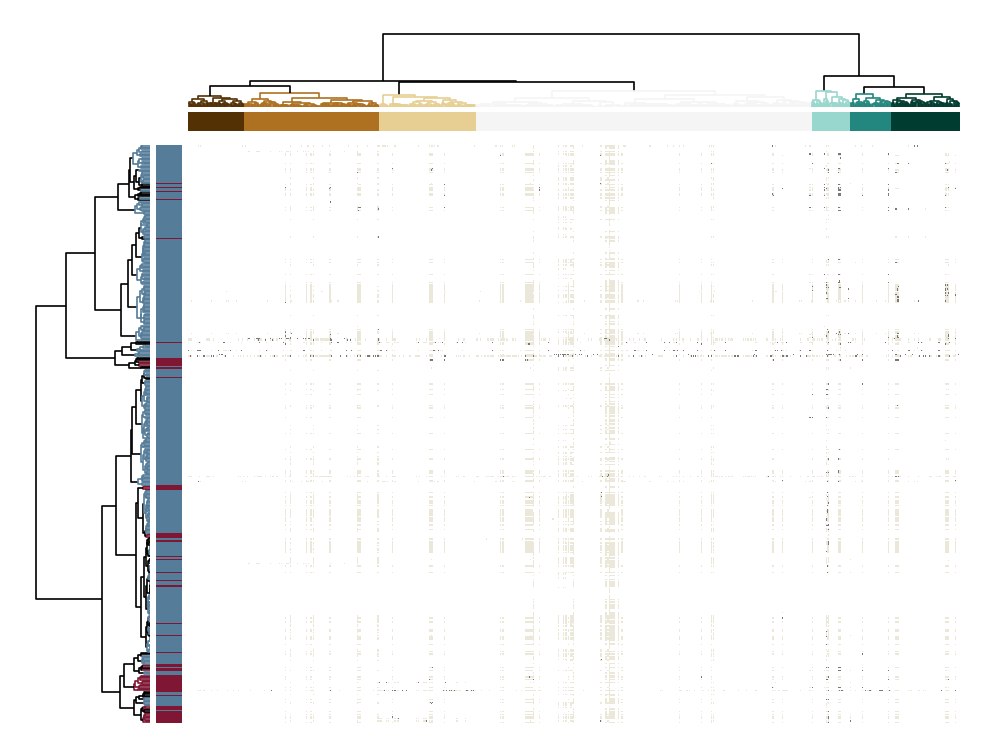

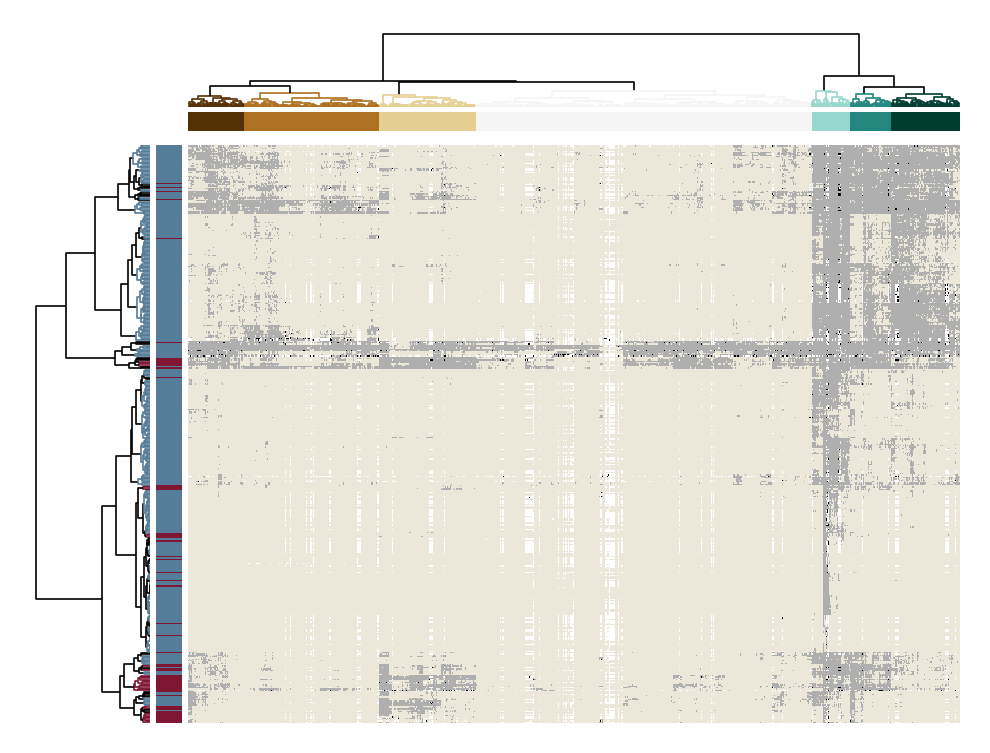

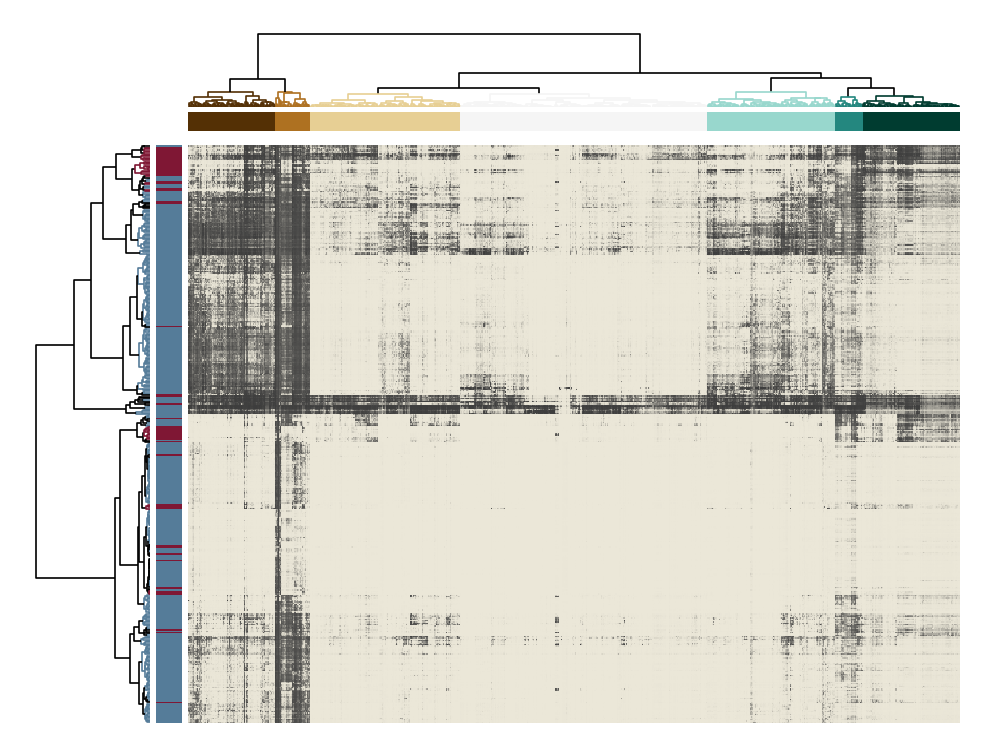

In [125]:
def _col_link_color(col_link, labels):
    c2c = {lab: EARTHY[(lab - 1) % len(EARTHY)] for lab in np.unique(labels)}
    def _f(node, n=len(labels)):
        if node < n:
            return c2c[labels[node]]
        l, r = (int(x) for x in col_link[node - n, :2])
        cl, cr = _f(l), _f(r)
        return cl if cl == cr else "black"
    return _f

def _row_link_color(row_link, classes, cmap):
    n = classes.shape[0]
    def _f(node):
        if node < n:
            return to_hex(cmap(min(int(classes[node, 0]), 1)))
        l, r = (int(x) for x in row_link[node - n, :2])
        cl, cr = _f(l), _f(r)
        return cl if cl == cr else "#000000"
    return _f

def plot_clustered(data, clu, title, cmap, norm, masked=False):
    """One clustered panel: col dendro+stripe, row dendro+class stripe, heatmap."""
    M = np.ma.masked_invalid(data) if masked else data
    labels, col_link, row_link = clu["labels"], clu["col_link"], clu["row_link"]

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
    gs = gridspec.GridSpec(4, 3, height_ratios=[1.2, 0.3, 0.05, 9.0],
                           width_ratios=[1.4, 0.3, 9.0], hspace=0.03, wspace=0.02)

    ax_cd = fig.add_subplot(gs[0, 2])
    col_d = dendrogram(col_link, ax=ax_cd, no_labels=True, color_threshold=0,
                       link_color_func=_col_link_color(col_link, labels))
    for c in ax_cd.collections:
        c.set_linewidth(0.4)
    ax_cd.axis("off"); col_leaves = col_d["leaves"]

    ax_cs = fig.add_subplot(gs[1, 2])
    ax_cs.imshow((labels[col_leaves] - 1).reshape(1, -1), aspect="auto", interpolation="nearest",
                 cmap=cluster_cmap,
                 norm=BoundaryNorm(np.arange(-0.5, cluster_cmap.N + 0.5), cluster_cmap.N))
    ax_cs.axis("off")

    ax_rd = fig.add_subplot(gs[3, 0])
    row_d = dendrogram(row_link, ax=ax_rd, orientation="left", no_labels=True, color_threshold=0,
                       link_color_func=_row_link_color(row_link, row_classes, row_cmap))
    for c in ax_rd.collections:
        c.set_linewidth(0.4)
    ax_rd.axis("off"); row_leaves = row_d["leaves"]

    ax_rs = fig.add_subplot(gs[3, 1])
    ax_rs.imshow(np.flipud(row_classes[row_leaves, :].clip(max=1)), aspect="auto",
                 interpolation="nearest", cmap=row_cmap, norm=row_norm)
    ax_rs.axis("off")

    ax_h = fig.add_subplot(gs[3, 2])
    ax_h.imshow(np.flipud(M[np.ix_(row_leaves, col_leaves)]), aspect="auto",
                interpolation="nearest", cmap=cmap, norm=norm)
    ax_h.axis("off")

    savefig(fig, title); plt.show(); plt.close(fig)

# --- experimental (ground truth) ---
plot_clustered(exp_mat_ext.to_numpy(float), clu_bin,
               "experimental_human_clustering", heat_cmap, heat_norm, masked=True)

# --- predicted binary + gold/red overlay (main) ---
plot_clustered(pred_cat.to_numpy(int), clu_bin,
               "predicted_binary_human_clustering", pred_cmap, pred_norm)

# --- predicted probability (supplementary) ---
plot_clustered(pred_prob_ext.to_numpy(float), clu_prob,
               "predicted_probability_human_clustering", prob_cmap, prob_norm)

## 6 · Heatmaps — phylogenetic tree order

Same matrices, but receptor rows follow the human OR reference tree. Columns keep the binary
clustering order so all three panels stay directly comparable.

In [126]:
tree = Phylo.read(StringIO(open(TREE_PATH).readline().strip()), "newick")

def _leaf_to_uniprot(name):
    tok = name.strip()
    if "." in tok and tok.split(".", 1)[0].isdigit():
        tok = tok.split(".", 1)[1]
    if "|" in tok:
        tok = tok.split("|")[1]
    return tok.split("-", 1)[0]

leaf_order = []
for t in tree.get_terminals():
    if not t.name:
        continue
    up  = _leaf_to_uniprot(t.name)
    key = uniprot2seq.get(up, f"UP:{up}")
    if key in exp_mat_ext.index:
        leaf_order.append(key)

print(f"tree leaves mapped onto matrix rows: {len(leaf_order)} / {exp_mat_ext.shape[0]}")
assert len(leaf_order) == exp_mat_ext.shape[0], "some tree leaves did not map onto matrix rows"

# fixed column order + cluster stripe from the binary clustering
col_order = clu_bin["col_order"]
labels    = clu_bin["labels"]
col_link  = clu_bin["col_link"]
cols      = exp_mat_ext.columns[col_order]

tree_row_classes = row_class_codes(pd.Index(leaf_order)).clip(max=1)

tree leaves mapped onto matrix rows: 433 / 433


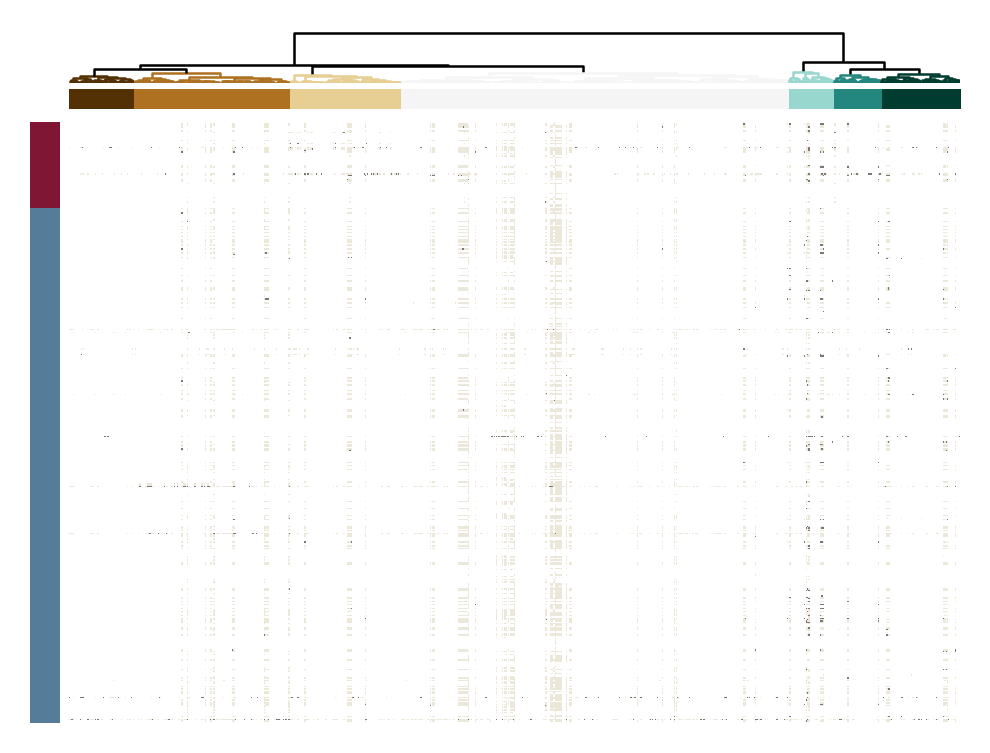

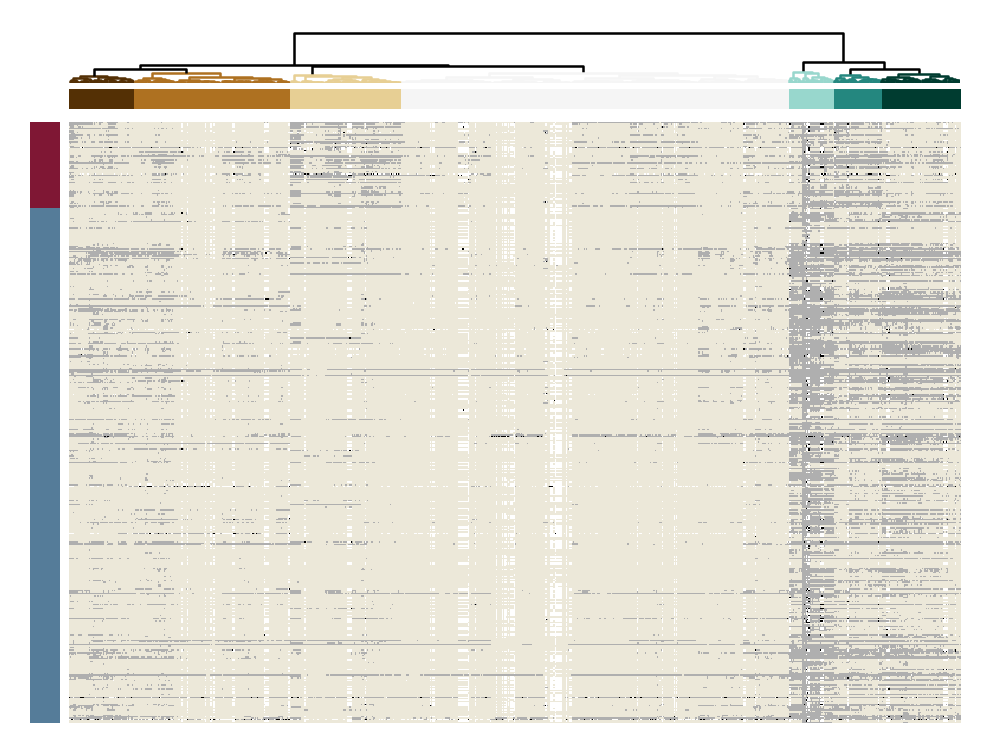

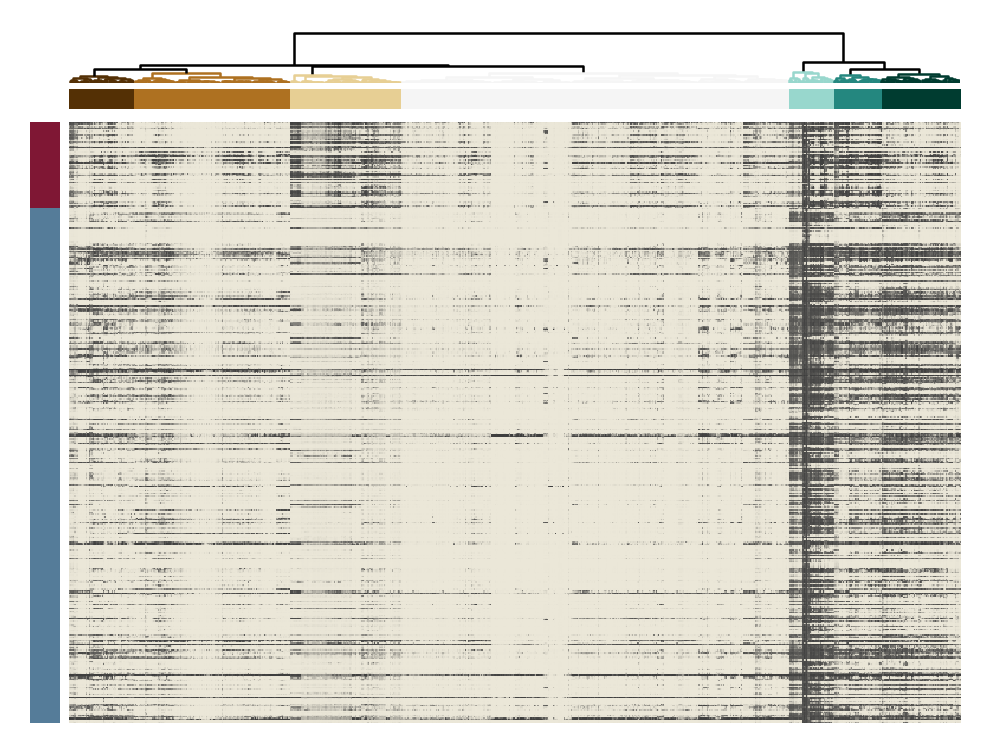

In [127]:
def plot_tree_order(mat_df, title, cmap, norm, masked=False):
    data = mat_df.loc[leaf_order, cols].to_numpy()
    data = np.ma.masked_invalid(data.astype(float)) if masked else data

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
    gs = gridspec.GridSpec(4, 2, height_ratios=[0.8, 0.3, 0.05, 9.0],
                           width_ratios=[0.3, 9.0], hspace=0.03, wspace=0.02)

    ax_d = fig.add_subplot(gs[0, 1])
    dendrogram(col_link, ax=ax_d, no_labels=True, color_threshold=0,
               link_color_func=_col_link_color(col_link, labels))
    for c in ax_d.collections:
        c.set_linewidth(0.6)
    ax_d.axis("off")

    ax_cs = fig.add_subplot(gs[1, 1])
    ax_cs.imshow((labels[col_order] - 1).reshape(1, -1), aspect="auto", interpolation="nearest",
                 cmap=cluster_cmap,
                 norm=BoundaryNorm(np.arange(-0.5, cluster_cmap.N + 0.5), cluster_cmap.N))
    ax_cs.axis("off")

    ax_rs = fig.add_subplot(gs[3, 0])
    ax_rs.imshow(tree_row_classes, aspect="auto", interpolation="nearest",
                 cmap=row_cmap, norm=row_norm)
    ax_rs.axis("off")

    ax_h = fig.add_subplot(gs[3, 1])
    ax_h.imshow(data, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)
    ax_h.axis("off")

    savefig(fig, title); plt.show(); plt.close(fig)

plot_tree_order(exp_mat_ext,   "experimental_human_tree",           heat_cmap, heat_norm, masked=True)
plot_tree_order(pred_cat,      "predicted_binary_human_tree",       pred_cmap, pred_norm)
plot_tree_order(pred_prob_ext, "predicted_probability_human_tree",  prob_cmap, prob_norm)

## 7 · Legend

In [128]:
handles = [
    Patch(facecolor="#3b3b3b", label="Responsive (predicted)"),
    Patch(facecolor="#ece8d9", label="Non-responsive (predicted)"),
    Patch(facecolor="white", edgecolor="0.5", label="Not tested"),
    Patch(facecolor=GOLD, label="Experimentally responsive"),
    Patch(facecolor=RED,  label="Experimentally non-responsive"),
    Patch(facecolor=row_cmap(0.0), label="Class I"),
    Patch(facecolor=row_cmap(1.0), label="Class II"),
]
handles += [Patch(facecolor=EARTHY[i], label=f"Ligand cluster {i + 1}")
            for i in range(N_CLUSTERS)]

figL = plt.figure(figsize=(2.4, 0.32 * len(handles) + 0.4))
figL.legend(handles=handles, loc="center", frameon=False)
savefig(figL, "heatmap_legend"); plt.show(); plt.close(figL)

<Figure size 240x488 with 0 Axes>